In [1]:
import os

broken_path = "/cluster/tufts/apps/manual/9/x86_64/jupyter/4.5.0/bin"

if broken_path in os.environ.get("PATH", ""):
    os.environ["PATH"] = os.environ["PATH"].replace(broken_path + ":", "").replace(broken_path, "")

import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams.update({
    "font.size": 10,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
import copy
import random
import itertools
import numpy as np
import pandas as pd
import torch


In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import approximate_posteriors
import layers
import utils


In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


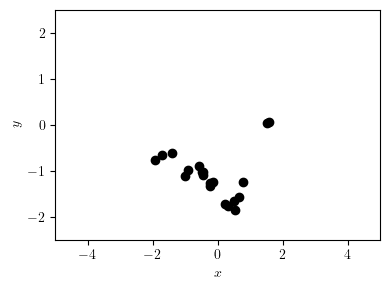

In [5]:
N = 20
D = 1
X_numpy = np.random.randn(N, D)
#K = utils.rbf_kernel(X_numpy, X_numpy, lengthscale=1.0, outputscale=1.0)
K = utils.matern_kernel(X_numpy, X_numpy, lengthscale=1.0, nu=2.5, outputscale=1.0)
#y_numpy = np.sin(3 * np.sum(X_numpy, axis=1, keepdims=True)) + 0.1 * np.random.randn(N, 1)
y_numpy = np.random.multivariate_normal(mean=np.zeros(N), cov=K, size=1).reshape(N, 1) + 0.1 * np.random.randn(N, 1)

X = torch.tensor(X_numpy.reshape(-1, 1), dtype=torch.float64)
y = torch.tensor(y_numpy.reshape(-1, 1), dtype=torch.float64)

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows)

ax.scatter(X_numpy, y_numpy, color="#000000")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim([-5, 5])
ax.set_ylim([-2.5, 2.5])

fig.tight_layout()
plt.show()


In [6]:
phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
init_state_dict = copy.deepcopy(phi.state_dict())


In [7]:
phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
model = approximate_posteriors.FullRankCovariance(
    m = None,
    S = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
        
    fullrank_sigma_f = model.sigma_f
    fullrank_sigma_n2 = model.sigma_n2
    
    Phi = phi(X)
    
    sigma_f_vals = np.logspace(-2, 2, 101)
    sigma_n2_vals = np.logspace(-4, 0, 101)
    
    fullrank_elbos = []
    fullrank_lmls = []
    
    for sigma_n2, sigma_f in itertools.product(sigma_n2_vals, sigma_f_vals):
        model.sigma_f = torch.tensor([sigma_f], dtype=torch.float64)
        model.sigma_n2 = torch.tensor([sigma_n2], dtype=torch.float64)
        elbo_val = model.elbo(Phi, y).item() 
        lml_val = model.lml(Phi, y).item() 
        fullrank_elbos.append(elbo_val)
        fullrank_lmls.append(lml_val)

In [8]:
phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
model = approximate_posteriors.DiagonalCovariance(
    m = None,
    s = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
        
    diagonal_sigma_f = model.sigma_f
    diagonal_sigma_n2 = model.sigma_n2
    
    Phi = phi(X)
    
    sigma_f_vals = np.logspace(-2, 2, 101)
    sigma_n2_vals = np.logspace(-4, 0, 101)
    
    diagonal_elbos = []
    
    for sigma_n2, sigma_f in itertools.product(sigma_n2_vals, sigma_f_vals):
        model.sigma_f = torch.tensor([sigma_f], dtype=torch.float64)
        model.sigma_n2 = torch.tensor([sigma_n2], dtype=torch.float64)
        elbo_val = model.elbo(Phi, y).item() 
        diagonal_elbos.append(elbo_val)

In [9]:
phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
k = 512
model = approximate_posteriors.LowRankPlusDiagonalCovariance(
    C = None,
    d_2 = None,
    k = torch.tensor(k, dtype=torch.int64),
    L = None,
    m = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])

with torch.no_grad():
    
    lowrank_plus_diagonal_sigma_f = model.sigma_f
    lowrank_plus_diagonal_sigma_n2 = model.sigma_n2
    
    Phi = phi(X)
    
    sigma_f_vals = np.logspace(-2, 2, 101)
    sigma_n2_vals = np.logspace(-4, 0, 101)
    
    lowrank_plus_diagonal_elbos = []
    
    for sigma_n2, sigma_f in itertools.product(sigma_n2_vals, sigma_f_vals):
        model.sigma_f = torch.tensor([sigma_f], dtype=torch.float64)
        model.sigma_n2 = torch.tensor([sigma_n2], dtype=torch.float64)
        elbo_val = model.elbo(Phi, y).item() 
        lowrank_plus_diagonal_elbos.append(elbo_val)

In [10]:
phi = layers.RBFRFFs(D=D, learnable_lengthscale=True, learnable_outputscale=False, lengthscale=1.0, outputscale=1.0, R=1_024)
phi.load_state_dict(init_state_dict)
k = 512
model = approximate_posteriors.LowRankCovariance(
    C = None,
    d_2 = 1e-6 * torch.ones((1_024 - k,), dtype=torch.float64),
    k = torch.tensor(k, dtype=torch.int64),
    L = None,
    m = None,
    sigma_f = torch.tensor([1.0], dtype=torch.float64),
    sigma_n2 = torch.tensor([1.0], dtype=torch.float64),
    tau = torch.tensor([1.0], dtype=torch.float64),
    temp = torch.tensor([1.0], dtype=torch.float64),
    cold = torch.tensor([1.0], dtype=torch.float64),
)
elbos, lmls, best_checkpoint = utils.cavi_and_adam(X, y, phi, model, num_epochs=500)
elbos, lmls, best_checkpoint = utils.cavi(X, y, phi, model, num_epochs=500)
phi.load_state_dict(best_checkpoint["phi"])
model.load_state_dict(best_checkpoint["model"])


with torch.no_grad():
    
    lowrank_sigma_f = model.sigma_f
    lowrank_sigma_n2 = model.sigma_n2
    
    Phi = phi(X)
    
    sigma_f_vals = np.logspace(-2, 2, 101)
    sigma_n2_vals = np.logspace(-4, 0, 101)
    
    lowrank_elbos = []
    
    for sigma_n2, sigma_f in itertools.product(sigma_n2_vals, sigma_f_vals):
        model.sigma_f = torch.tensor([sigma_f], dtype=torch.float64)
        model.sigma_n2 = torch.tensor([sigma_n2], dtype=torch.float64)
        elbo_val = model.elbo(Phi, y).item() 
        lowrank_elbos.append(elbo_val)

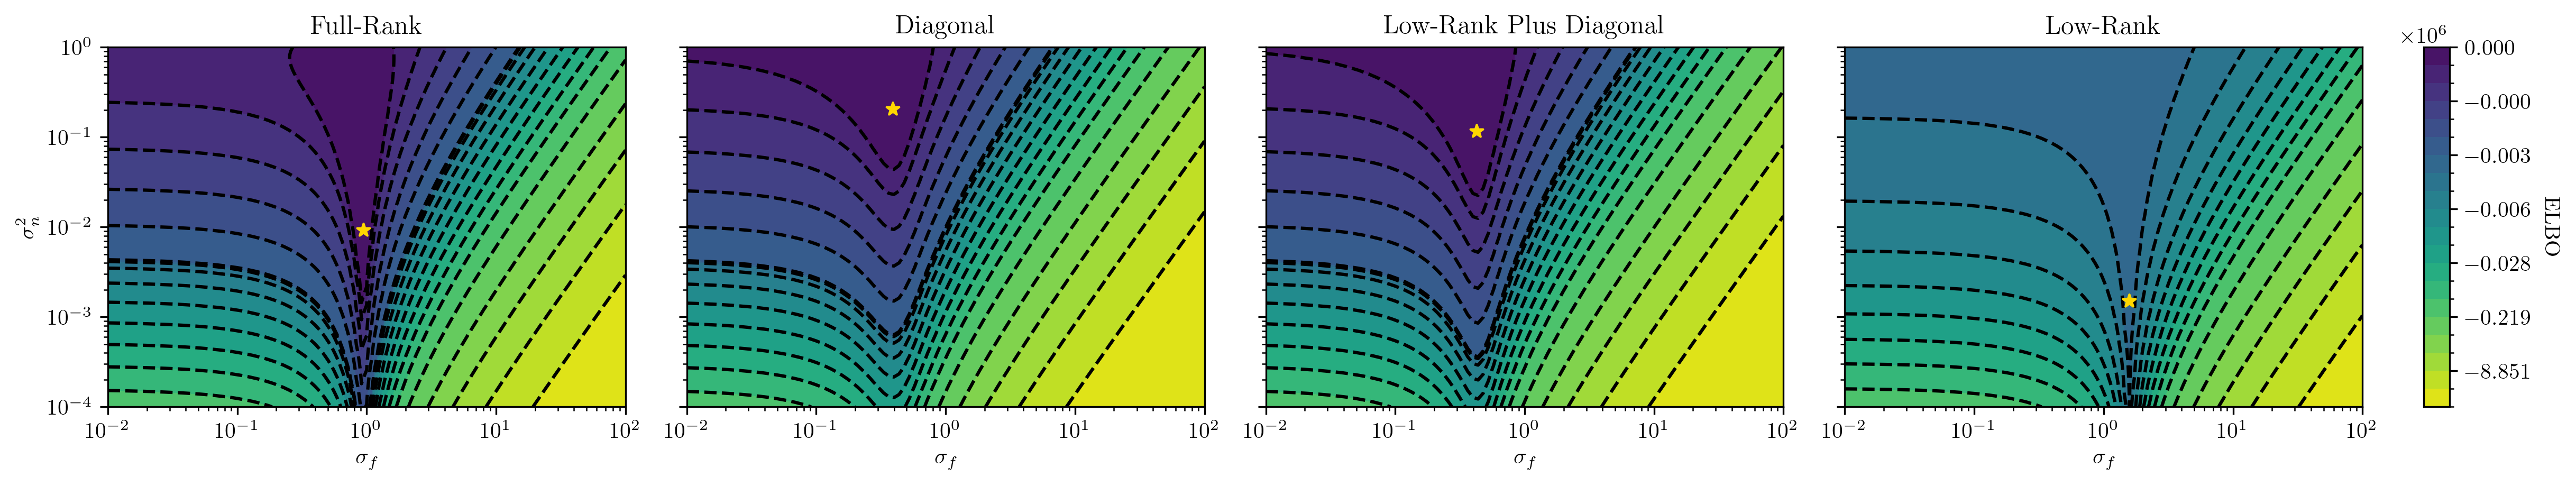

In [11]:
sigma_f_vals = np.logspace(-2, 2, 101)
sigma_n2_vals = np.logspace(-4, 0, 101)

ncols, nrows = 4, 1
zoom = 2.5
latex_width_pts = 487.8225
inches_per_pt = 1.0 / 72.27
figure_width_inches = latex_width_pts * inches_per_pt
figure_height_inches = (3 / 4) * (nrows / ncols) * figure_width_inches

fig, axs = plt.subplots(dpi=300, figsize=(zoom * figure_width_inches, zoom * figure_height_inches), ncols=ncols, nrows=nrows, sharey="row")

fullrank_Z = np.array(fullrank_elbos).reshape(len(sigma_f_vals), len(sigma_n2_vals))
diagonal_Z = np.array(diagonal_elbos).reshape(len(sigma_f_vals), len(sigma_n2_vals))
lowrank_plus_diagonal_Z = np.array(lowrank_plus_diagonal_elbos).reshape(len(sigma_f_vals), len(sigma_n2_vals))
lowrank_Z = np.array(lowrank_elbos).reshape(len(sigma_f_vals), len(sigma_n2_vals))

X_grid, Y_grid = np.meshgrid(sigma_f_vals, sigma_n2_vals)

all_Z = np.concatenate([fullrank_elbos, diagonal_elbos, lowrank_plus_diagonal_elbos, lowrank_elbos])
levels = np.unique(np.percentile(all_Z, np.linspace(0, 100, 21)))
norm = colors.BoundaryNorm(levels, ncolors=256, extend="both")

cp = axs[0].contourf(X_grid, Y_grid, fullrank_Z, levels=levels, cmap="viridis_r", norm=norm)
axs[0].contour(X_grid, Y_grid, fullrank_Z, colors="black", levels=levels, norm=norm)
axs[0].scatter(fullrank_sigma_f, fullrank_sigma_n2, color="gold", marker="*", zorder=2)
axs[0].set_title("Full-Rank")
axs[0].set_xlabel(r"$\sigma_f$")
axs[0].set_ylabel(r"$\sigma_n^2$")
axs[0].set_xscale("log")
axs[0].set_yscale("log")

cp = axs[1].contourf(X_grid, Y_grid, diagonal_Z, levels=levels, cmap="viridis_r", norm=norm)
axs[1].contour(X_grid, Y_grid, diagonal_Z, colors="black", levels=levels, norm=norm)
axs[1].scatter(diagonal_sigma_f, diagonal_sigma_n2, color="gold", marker="*", zorder=2)
axs[1].set_title("Diagonal")
axs[1].set_xlabel(r"$\sigma_f$")
axs[1].set_xscale("log")
axs[1].set_yscale("log")

cp = axs[2].contourf(X_grid, Y_grid, lowrank_plus_diagonal_Z, levels=levels, cmap="viridis_r", norm=norm)
axs[2].contour(X_grid, Y_grid, lowrank_plus_diagonal_Z, colors="black", levels=levels, norm=norm)
axs[2].scatter(lowrank_plus_diagonal_sigma_f, lowrank_plus_diagonal_sigma_n2, color="gold", marker="*", zorder=2)
axs[2].set_title("Low-Rank Plus Diagonal")
axs[2].set_xlabel(r"$\sigma_f$")
axs[2].set_xscale("log")
axs[2].set_yscale("log")

cp = axs[3].contourf(X_grid, Y_grid, lowrank_Z, levels=levels, cmap="viridis_r", norm=norm)
axs[3].contour(X_grid, Y_grid, lowrank_Z, colors="black", levels=levels, norm=norm)
axs[3].scatter(lowrank_sigma_f, lowrank_sigma_n2, color="gold", marker="*", zorder=2)
axs[3].set_title("Low-Rank")
axs[3].set_xlabel(r"$\sigma_f$")
axs[3].set_xscale("log")
axs[3].set_yscale("log")

fig.tight_layout(rect=[0, 0, 0.9, 1.0])

pos0 = axs[-1].get_position()
pos1 = axs[-2].get_position()

pad = (pos0.x0 - pos1.x1)
width = 0.05 * pos0.width

cbar_ax = fig.add_axes([pos0.x1 + pad, pos0.y0, width, pos0.height])
cbar = fig.colorbar(cp, cax=cbar_ax)
cbar.set_label("ELBO", rotation=270, va="bottom")

plt.show()
fig.savefig("varying_signal_and_noise.pdf", bbox_inches="tight")
plt.show()

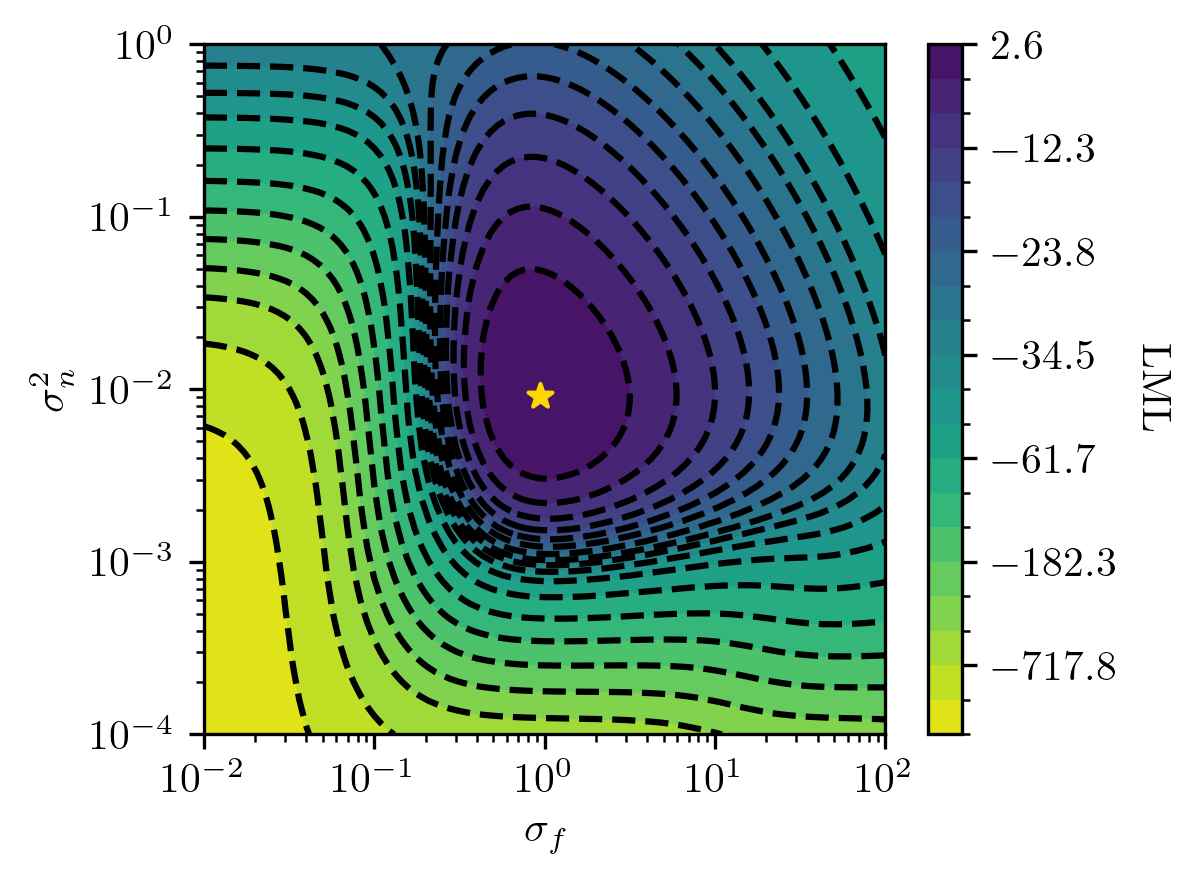

In [12]:
sigma_f_vals = np.logspace(-2, 2, 101)
sigma_n2_vals = np.logspace(-4, 0, 101)

ncols, nrows = 1, 1
zoom = 2.5
latex_width_pts = 234.8775 / 2
inches_per_pt = 1.0 / 72.27
figure_width_inches = latex_width_pts * inches_per_pt
figure_height_inches = (3 / 4) * (nrows / ncols) * figure_width_inches

fig, ax = plt.subplots(dpi=300, figsize=(zoom * figure_width_inches, zoom * figure_height_inches), ncols=ncols, nrows=nrows)

fullrank_Z = np.array(fullrank_lmls).reshape(len(sigma_f_vals), len(sigma_n2_vals))

X_grid, Y_grid = np.meshgrid(sigma_f_vals, sigma_n2_vals)

all_Z = np.concatenate([fullrank_Z])
levels = np.unique(np.percentile(all_Z, np.linspace(0, 100, 21)))
norm = colors.BoundaryNorm(levels, ncolors=256, extend="both")

cp = ax.contourf(X_grid, Y_grid, fullrank_Z, levels=levels, cmap="viridis_r", norm=norm)
ax.contour(X_grid, Y_grid, fullrank_Z, colors="black", levels=levels, norm=norm)
ax.scatter(fullrank_sigma_f, fullrank_sigma_n2, color="gold", marker="*", zorder=2)
ax.set_xlabel(r"$\sigma_f$")
ax.set_ylabel(r"$\sigma_n^2$")
ax.set_xscale("log")
ax.set_yscale("log")

cbar = fig.colorbar(cp, ax=ax)
cbar.set_label("LML", rotation=270, va="bottom")

fig.tight_layout()
plt.show()